In [1]:
# !pip install legacy-cgi

In [2]:
import os
import subprocess
from pathlib import Path
from PIL import Image
## dataset and Visualization
import numpy as np
import pandas as np
import matplotlib.pyplot as plt
import opendatasets as od
import random
## Torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

##Torchvision
from torchvision import datasets,transforms

In [3]:
repo_name = "machine-learning-projects"
repo_path = f'/content/{repo_name}'
repo_url = f"https://github.com/Ebenezeragyemang10/{repo_name}"
sub_working_dir = "chest-x-ray-classification-cnn"


if not os.path.isdir(repo_path):
  print("cloning")
  subprocess.run(["git", "clone", repo_url])

else:
  print("directory already exist....")


target_dir = os.path.join(repo_path, sub_working_dir) if sub_working_dir else repo_path
os.chdir(target_dir)

directory already exist....


In [4]:
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data",

)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Ebenezer Agyemang
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:30<00:00, 80.3MB/s]


In [5]:
dataset_dir = f'{target_dir}/chest-xray-pneumonia/chest_xray'
train_dir = f'{dataset_dir}/train'
test_dir = f'{dataset_dir}/test'
valid_dir = f'{dataset_dir}/val'


In [6]:
## Visualize the data

In [7]:
print(f"Total training normal xrays: {len(os.listdir(train_dir + "/NORMAL"))}")
print(f"Total training Pneumonia xrays: {len(os.listdir(train_dir + "/PNEUMONIA"))}")
print(f"Total testing normal xrays: {len(os.listdir(test_dir + "/NORMAL"))}")
print(f"Total testing Pneumonia xrays: {len(os.listdir(test_dir + "/PNEUMONIA"))}")

Total training normal xrays: 1341
Total training Pneumonia xrays: 3875
Total testing normal xrays: 234
Total testing Pneumonia xrays: 390


In [8]:
normal_train = os.listdir(f'{train_dir}/NORMAL')
pneumonia_train = os.listdir(f'{train_dir}/PNEUMONIA')
normal_test  = os.listdir(f'{test_dir}/NORMAL')
pneumonia_test = os.listdir(f'{test_dir}/PNEUMONIA')


In [9]:
train_count = [
    len(normal_train),
    len(pneumonia_train)
]
print(train_count)
classes = [
    "Normal",
    "Pneumonia"
]

[1341, 3875]


Text(0, 0.5, 'xray class Count')

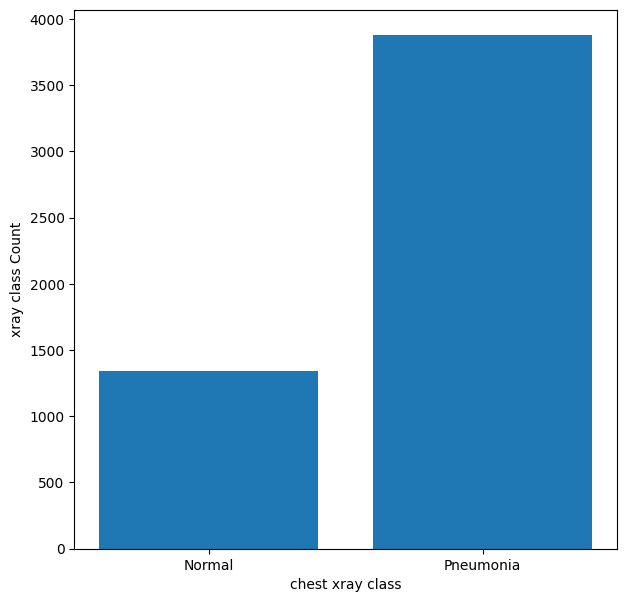

In [10]:
plt.figure(figsize=(7, 7))
plt.bar(classes,train_count)
plt.xlabel("chest xray class")
plt.ylabel("xray class Count")

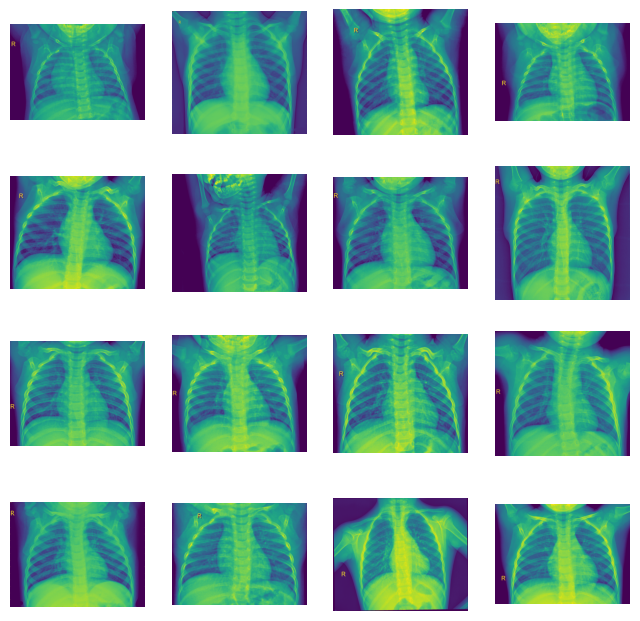

In [11]:
#visualizing normal train images
nrows, ncols = 4, 4
plt.figure(figsize=(8, 8))
for i in range(1, nrows*ncols+1):
  random_image_name  = random.choice(normal_train)
  random_image_path = f"{train_dir}/NORMAL/{random_image_name}"
  image= Image.open(random_image_path)
  plt.subplot(nrows, ncols, i)
  plt.imshow(image)
  plt.axis("OFF")


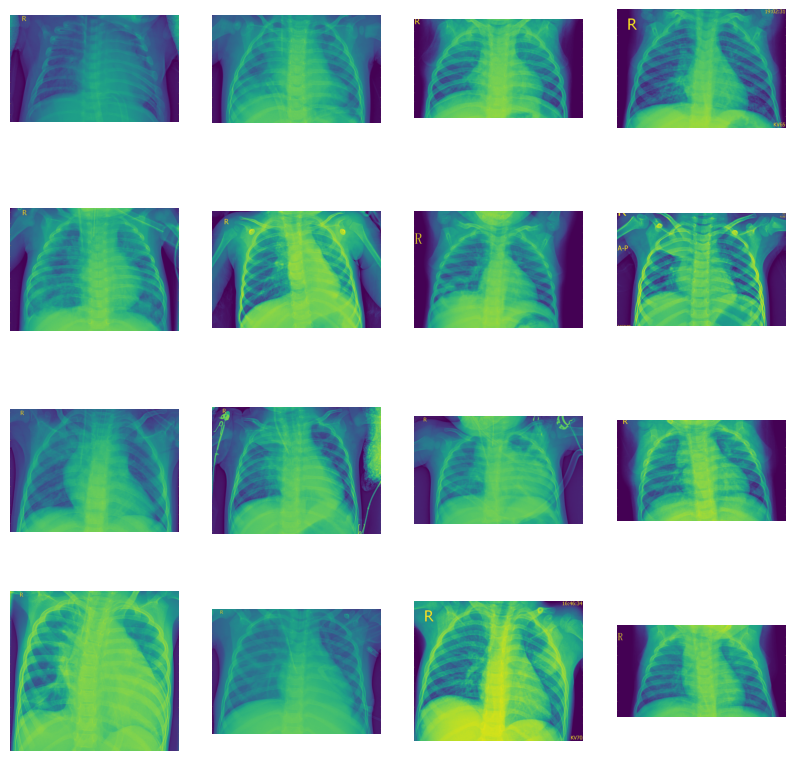

In [12]:
## Visualizing Pneumonia Xray Images
num_cols = 4
num_rows = 4
plt.figure(figsize=(10, 10))
for i in range(1, num_cols*num_rows+1):
  random_image = random.choice(pneumonia_train)
  random_image_name =  f"{train_dir}/PNEUMONIA/{random_image}"
  image = Image.open(random_image_name)
  plt.subplot(num_rows, num_cols, i)
  plt.imshow(image)
  plt.axis("OFF")






image path: /content/machine-learning-projects/chest-x-ray-classification-cnn/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0210-0001.jpeg
image format: JPEG
image size: (1688, 1105)


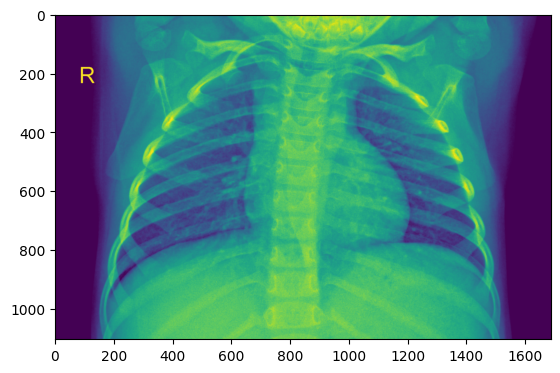

In [13]:
random_normal_xray = random.choice(normal_train)
image_path = f'{train_dir}/NORMAL/{random_normal_xray}'
img = Image.open(image_path)
plt.imshow(img)
print("image path:", image_path)
print("image format:", img.format)
print("image size:", img.size)

In [14]:
train_transforms = transforms.Compose([
    transforms.Resize(size=(256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
    ]
)

In [15]:

BATCH_SIZE = 32
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

In [16]:
print(f'classes : { train_dataset.classes}')
print(f'classes tndices: { train_dataset.class_to_idx}')

classes : ['NORMAL', 'PNEUMONIA']
classes tndices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [16]:
### Define Model

class XrayNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding="same"),
        nn.batchnorm2d(32)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same"),
        nn.batchnorm
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

    )

